# DRIMC Simulation — Local Notebook Runner Test

Pairwise-CV protocol (same as the HPC masked scripts): 

outer doCrossValidationByPairwise on the OBSERVED matrix R_noisy, 

nested inner CV for HP selection, 

outer test scored against the clean truth R. 

Parallelised by opening several notebooks, each owning a slice of DATASET_IDS.

## Cell 1 — Configure which datasets this notebook runs

In [2]:
# ============================================================
# USER SETTINGS — change these per notebook instance
# ============================================================

# A unique label for this notebook — used in the output filename
# e.g. 'nb0', 'nb1', 'nb2' ... open one notebook per label
NOTEBOOK_ID = "nb1"

# Which dataset_grid indices (i_ds) this notebook will process.
# dataset_grid has 100 entries (10 feature sizes x 10 repeats),
# indexed 0..99. Split them across notebooks however you like.
#
# Example splits across 4 notebooks:
#   nb0: list(range(0,  25))   # feature_id 0-1, all repeats
#   nb1: list(range(25, 50))   # feature_id 2-3, all repeats
#   nb2: list(range(50, 75))   # feature_id 4-6, all repeats
#   nb3: list(range(75, 100))  # feature_id 7-9, all repeats
#
# Or by repeat_id if you prefer:
#   nb0: [i for i in range(100) if (i % 10) < 5]   # repeat_id 0-4
#   nb1: [i for i in range(100) if (i % 10) >= 5]  # repeat_id 5-9

DATASET_IDS = list(range(0, 1))  # <-- change this per notebook

BASE_SEED = 123456  # must match HPC runs for reproducible splits

# ============================================================

## Cell 2 — Paths

In [3]:
import os
import sys
import gzip
import pickle
import warnings
import logging

import numpy as np
from tqdm import TqdmSynchronisationWarning, tqdm

warnings.simplefilter("ignore", TqdmSynchronisationWarning)

# ====== user paths — adjust to your local machine ======
PATH_ROOT = "/Users/sijianfan/projects/BiSSGL"  # <-- change to local root
PATH_DATA = os.path.join(PATH_ROOT, "datasets/simulations/masked_ones")
PATH_OUTPUT = os.path.join(PATH_ROOT, "outputs/results/simulations/masked_ones")
PATH_ARCHIVE = os.path.join(PATH_OUTPUT, "archived")
DRIMC_PATH = os.path.join(PATH_ROOT, "scripts/methods/DRIMC")

for p in (PATH_OUTPUT, PATH_ARCHIVE):
    os.makedirs(p, exist_ok=True)

sys.path.append(PATH_ROOT)

print(f"Output will be saved to: {PATH_OUTPUT}")
print(f"Notebook ID: {NOTEBOOK_ID}  |  Datasets to run: {len(DATASET_IDS)}")

Output will be saved to: /Users/sijianfan/projects/BiSSGL/outputs/results/simulations/masked_ones
Notebook ID: nb1  |  Datasets to run: 1


## Cell 3 — Imports

In [4]:
from sgimc.utils import mc_split, get_submatrix
from sklearn.metrics import pairwise_distances
from sklearn.model_selection import ParameterGrid, ShuffleSplit, train_test_split
from scipy.special import expit

## Cell 4 — R setup via rpy2

In [5]:
import rpy2.robjects as robjects

r = robjects.r
r(f'setwd("{DRIMC_PATH}")')

for pkg in ["matrixcalc", "data.table", "Rcpp", "ROCR", "Bolstad2", "MESS"]:
    r(f"library({pkg})")

for r_file in [
    "doCrossValidationByPairwise.R",
    "constrNeig.R",
    "calcLogLik.R",
    "calcDeriv.R",
    "updateUV.R",
]:
    r(f'source("{r_file}")')

r("library(Rcpp)")
for cpp_file in ["log1pexp.cpp", "sigmoid.cpp"]:
    r(f'sourceCpp("{cpp_file}")')

doCrossValidationByPairwise_R = r["doCrossValidationByPairwise"]
updateUV_R = r["updateUV"]
constrNeig_R = r["constrNeig"]
print("R setup complete.")

R callback write-console: data.table 1.17.8 using 6 threads (see ?getDTthreads).    
R callback write-console: Latest news: r-datatable.com
  


R setup complete.


## Cell 5 — Helper functions

In [6]:
def get_metrics(real_score, predict_score):
    sorted_predict_score = np.array(
        sorted(list(set(np.array(predict_score).flatten())))
    )
    sorted_predict_score_num = len(sorted_predict_score)
    thresholds = sorted_predict_score[
        np.int32(sorted_predict_score_num * np.arange(1, 1000) / 1000)
    ]
    thresholds = np.mat(thresholds)
    thresholds_num = thresholds.shape[1]
    predict_score_matrix = np.tile(predict_score, (thresholds_num, 1))
    negative_index = np.where(predict_score_matrix < thresholds.T)
    positive_index = np.where(predict_score_matrix >= thresholds.T)
    predict_score_matrix[negative_index] = 0
    predict_score_matrix[positive_index] = 1
    TP = predict_score_matrix.dot(real_score.T)
    FP = predict_score_matrix.sum(axis=1) - TP
    FN = real_score.sum() - TP
    TN = len(real_score.T) - TP - FP - FN
    fpr = FP / (FP + TN)
    tpr = TP / (TP + FN)
    ROC_dot_matrix = np.mat(sorted(np.column_stack((fpr, tpr)).tolist())).T
    ROC_dot_matrix.T[0] = [0, 0]
    ROC_dot_matrix = np.c_[ROC_dot_matrix, [1, 1]]
    x_ROC = ROC_dot_matrix[0].T
    y_ROC = ROC_dot_matrix[1].T
    auc = 0.5 * (x_ROC[1:] - x_ROC[:-1]).T * (y_ROC[:-1] + y_ROC[1:])
    recall_list = tpr
    precision_list = TP / (TP + FP)
    PR_dot_matrix = np.mat(
        sorted(np.column_stack((recall_list, precision_list)).tolist())
    ).T
    PR_dot_matrix.T[0] = [0, 1]
    PR_dot_matrix = np.c_[PR_dot_matrix, [1, 0]]
    x_PR = PR_dot_matrix[0].T
    y_PR = PR_dot_matrix[1].T
    aupr = 0.5 * (x_PR[1:] - x_PR[:-1]).T * (y_PR[:-1] + y_PR[1:])
    f1_score_list = 2 * TP / (len(real_score.T) + TP - TN)
    accuracy_list = (TP + TN) / len(real_score.T)
    specificity_list = TN / (TN + FP)
    max_index = np.argmax(f1_score_list)
    f1_score = f1_score_list[max_index]
    accuracy = accuracy_list[max_index]
    specificity = specificity_list[max_index]
    recall = recall_list[max_index]
    precision = precision_list[max_index]
    return [aupr[0, 0], auc[0, 0], f1_score, accuracy, recall, specificity, precision]


def to_r_matrix(arr):
    return r.matrix(
        robjects.FloatVector(arr.flatten()),
        byrow=True,
        nrow=arr.shape[0],
        ncol=arr.shape[1],
    )


def build_sim_matrices(U, V, K=3):
    simD = 1 - pairwise_distances(U[:, 0:24], metric="jaccard")
    simT = 1 - pairwise_distances(V[:, 0:24], metric="jaccard")
    simD = np.nan_to_num(simD, nan=0.0)
    simT = np.nan_to_num(simT, nan=0.0)
    np.fill_diagonal(simD, 1.0)
    np.fill_diagonal(simT, 1.0)
    lap = constrNeig_R(to_r_matrix(simD), to_r_matrix(simT), K=K)
    simD_R = lap.rx2("simD")
    simT_R = lap.rx2("simT")
    return np.array(simD_R), np.array(simT_R), simD_R, simT_R  # constrained np + R


def extract_fold(savedFolds, trial, fold):
    fold_data = savedFolds.rx2(trial + 1).rx2(fold + 1)
    Y_train = np.array(fold_data.rx2(7))
    test_label = np.array(fold_data.rx2(1)).flatten()
    test_row = np.array(fold_data.rx2(3)).flatten().astype(int) - 1
    test_col = np.array(fold_data.rx2(4)).flatten().astype(int) - 1
    known_drug_idx = np.array(fold_data.rx2(5)).flatten().astype(int)
    known_target_idx = np.array(fold_data.rx2(6)).flatten().astype(int)
    return Y_train, test_row, test_col, test_label, known_drug_idx, known_target_idx


print("Helpers defined.")

Helpers defined.


## Cell 6 — Build grids

In [29]:
n_features_grid = np.arange(50, 501, 50)
n_repeats = 10
filename_template = "data_feature_{:03d}_rep_{:02d}.gz"

dataset_grid = []
for feature_id, n_features in enumerate(n_features_grid):
    for repeat_id in range(n_repeats):
        dataset_grid.append(
            {
                "feature_id": int(feature_id),
                "n_features": int(n_features),
                "repeat_id": int(repeat_id),
                "filename": os.path.join(
                    PATH_DATA, filename_template.format(n_features, repeat_id)
                ),
            }
        )

# CV config
KFOLD = 10
NUMSPLIT_OUTER = 1
N_INNER_KFOLD = 10
N_INNER_EVAL = 3
DO_INNER_CV = False

grid_model = ParameterGrid(
    {
        "lamU": [2],
        "lamV": [2],
        "cc": [1, 5, 10],
        "iterpara": [0.125],
        "numLat": [25],
    }
)
n_m = len(list(grid_model))

my_ids = list(DATASET_IDS)
print(f"Datasets assigned : {len(my_ids)}")
print(f"Folds per dataset : {KFOLD}")
print(f"Hyperparam combos : {n_m}")
print(f"Total fits (outer): {len(my_ids) * KFOLD * n_m}")

Datasets assigned : 1
Folds per dataset : 10
Hyperparam combos : 3
Total fits (outer): 30


## Cell 7 — Run

Progress bars are shown per dataset.  
Results are **incrementally saved** after each dataset finishes — if the kernel dies mid-run you keep completed datasets.

In [61]:
def build_sim_matrices(U, V, K=3):
    simD = 1 - pairwise_distances(U[:, 0:24], metric="cosine")
    simT = 1 - pairwise_distances(V[:, 0:24], metric="cosine")
    simD = np.nan_to_num(simD, nan=0.0)
    simT = np.nan_to_num(simT, nan=0.0)
    np.fill_diagonal(simD, 1.0)
    np.fill_diagonal(simT, 1.0)
    lap = constrNeig_R(to_r_matrix(simD), to_r_matrix(simT), K=K)
    simD_R = lap.rx2("simD")
    simT_R = lap.rx2("simT")
    return np.array(simD_R), np.array(simT_R), simD_R, simT_R  # constrained np + R

array([[ 1.,  0., -0., ..., -0., -0., -0.],
       [ 0.,  1., -0., ...,  0.,  0.,  0.],
       [-0., -0.,  1., ...,  0., -0.,  0.],
       ...,
       [-0.,  0.,  0., ...,  1.,  0., -0.],
       [-0.,  0., -0., ...,  0.,  1.,  0.],
       [-0.,  0.,  0., ..., -0.,  0.,  1.]])

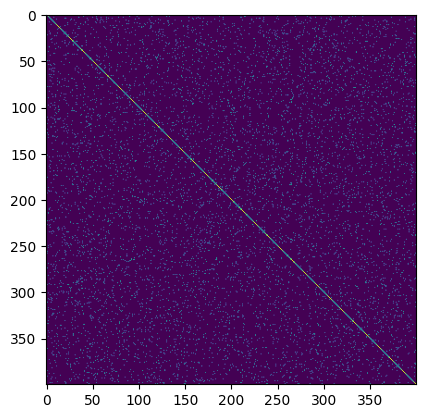

In [63]:
# from matplotlib import pyplot as plt
simD_np, simT_np, simD_R, simT_R = build_sim_matrices(U, V, K=20)
plt.imshow(simD_np)
simD_np

In [64]:
i_ds = 0

ds = dataset_grid[i_ds]

with gzip.open(ds["filename"], "rb") as fin:
    data = pickle.load(fin)
U = np.asarray(data["X"], dtype=float)
V = np.asarray(data["Y"], dtype=float)
R_true = np.asarray(data["R"], dtype=float)  # clean truth {0,1}
R_obs = np.asarray(data["R_noisy"], dtype=float)  # observed {0,1}

# similarity (constrained) — once per dataset
simD_np, simT_np, simD_R, simT_R = build_sim_matrices(U, V, K=0)

# outer pairwise folds on the OBSERVED matrix — once per dataset
outer_seed = (BASE_SEED + i_ds * 7919) % (2**31 - 1)
savedFolds = doCrossValidationByPairwise_R(
    to_r_matrix(R_obs),
    kfold=KFOLD,
    numSplit=NUMSPLIT_OUTER,
    seeds=robjects.IntVector([outer_seed]),
)

_inner_folds_cache = {}  # per (i_ds, fold), reused across HP combos
dataset_results = []

fold = 0

Y_train_dense, test_row, test_col, _obs_label, _, _ = extract_fold(
    savedFolds, 0, fold
)
test_label_true = R_true[test_row, test_col]


for i_m, par_mdl in enumerate(grid_model):
    # global combo index — matches the HPC flattening for seed parity
    combo_idx = i_ds * KFOLD * n_m + fold * n_m + i_m
    model_seed = BASE_SEED + combo_idx

    lamU = par_mdl["lamU"]
    lamV = par_mdl["lamV"]
    cc = par_mdl["cc"]
    iterpara = par_mdl["iterpara"]
    numLat = par_mdl["numLat"]

    try:
        out = updateUV_R(
            cc=cc,
            inMat=to_r_matrix(Y_train_dense),
            Sd=simD_R,
            St=simT_R,
            lamU=lamU,
            lamV=lamV,
            numLat=numLat,
            initMethod="useSeed",
            thisSeed=model_seed % (2**31 - 1),
            iterpara=iterpara,
            maxIter=100,
        )
        est_U = np.array(out.rx2("U"))
        est_V = np.array(out.rx2("V"))

        SA = simD_np @ est_U
        STB = simT_np @ est_V
        prob_full = expit(SA @ STB.T)
        prob_test = prob_full[test_row, test_col]
        scores_test = get_metrics(
            np.asarray(test_label_true, dtype=float),
            np.asarray(prob_test, dtype=float),
        )
        d1_test = int(sum(abs(est_U).max(axis=1) > 0))
        d2_test = int(sum(abs(est_V).max(axis=1) > 0))

        # ---- inner CV for HP selection (observed labels) ----
        inner_scores = []
        if DO_INNER_CV:
            if fold not in _inner_folds_cache:
                inner_seed = (BASE_SEED + i_ds * 7919 + fold + 31415) % (
                    2**31 - 1
                )
                _inner_folds_cache[fold] = doCrossValidationByPairwise_R(
                    to_r_matrix(Y_train_dense),
                    kfold=N_INNER_KFOLD,
                    numSplit=1,
                    seeds=robjects.IntVector([inner_seed]),
                )
            inner_savedFolds = _inner_folds_cache[fold]

            for cv in range(N_INNER_EVAL):
                Y_inner, val_row, val_col, val_label, _, _ = extract_fold(
                    inner_savedFolds, 0, cv
                )
                out_cv = updateUV_R(
                    cc=cc,
                    inMat=to_r_matrix(Y_inner),
                    Sd=simD_R,
                    St=simT_R,
                    lamU=lamU,
                    lamV=lamV,
                    numLat=numLat,
                    initMethod="useSeed",
                    thisSeed=model_seed % (2**31 - 1),
                    iterpara=iterpara,
                    maxIter=100,
                )
                est_U_cv = np.array(out_cv.rx2("U"))
                est_V_cv = np.array(out_cv.rx2("V"))
                SA_cv = simD_np @ est_U_cv
                STB_cv = simT_np @ est_V_cv
                prob_full_cv = expit(SA_cv @ STB_cv.T)
                prob_valid = prob_full_cv[val_row, val_col]
                scores_valid = get_metrics(
                    np.asarray(val_label, dtype=float),
                    np.asarray(prob_valid, dtype=float),
                )
                inner_scores.append(
                    (
                        int(cv),
                        scores_valid,
                        int(sum(abs(est_U_cv).max(axis=1) > 0)),
                        int(sum(abs(est_V_cv).max(axis=1) > 0)),
                    )
                )
        else:
            inner_scores.append((-1, [np.nan] * 7, -1, -1))

        for cv, scores_valid, d1_valid, d2_valid in inner_scores:
            dataset_results.append(
                {
                    "feature_id": ds["feature_id"],
                    "n_features": ds["n_features"],
                    "repeat_id": ds["repeat_id"],
                    "fold": int(fold),
                    "lamU": lamU,
                    "lamV": lamV,
                    "cc": cc,
                    "iterpara": iterpara,
                    "numLat": numLat,
                    "cv": int(cv),
                    "val_score": scores_valid,
                    "val_d1": d1_valid,
                    "val_d2": d2_valid,
                    "test_score": scores_test,
                    "test_d1": d1_test,
                    "test_d2": d2_test,
                }
            )

    except Exception as e:
        print(
            f"  ERROR i_ds={i_ds} fold={fold} "
            f"lamU={lamU} lamV={lamV} cc={cc}: {e}"
        )

In [65]:
# all_results = []
# all_results.extend(dataset_results)

dataset_results

[{'feature_id': 0,
  'n_features': 50,
  'repeat_id': 0,
  'fold': 0,
  'lamU': 2,
  'lamV': 2,
  'cc': 1,
  'iterpara': 0.125,
  'numLat': 25,
  'cv': -1,
  'val_score': [nan, nan, nan, nan, nan, nan, nan],
  'val_d1': -1,
  'val_d2': -1,
  'test_score': [0.029268046951612683,
   0.7070933949985467,
   0.06345047559378025,
   0.8497882894610631,
   0.3800750597065848,
   0.8561620370370371,
   0.03461454805332007],
  'test_d1': 400,
  'test_d2': 600},
 {'feature_id': 0,
  'n_features': 50,
  'repeat_id': 0,
  'fold': 0,
  'lamU': 2,
  'lamV': 2,
  'cc': 5,
  'iterpara': 0.125,
  'numLat': 25,
  'cv': -1,
  'val_score': [nan, nan, nan, nan, nan, nan, nan],
  'val_d1': -1,
  'val_d2': -1,
  'test_score': [0.06527722545755767,
   0.8383027810948103,
   0.12537697137489495,
   0.9191937185688641,
   0.4326168543159331,
   0.9257962962962963,
   0.07331174838112858],
  'test_d1': 400,
  'test_d2': 600},
 {'feature_id': 0,
  'n_features': 50,
  'repeat_id': 0,
  'fold': 0,
  'lamU': 2,
  'l